<a href="https://colab.research.google.com/github/aini43325018-ui/2025_algoritma_dan_pemrograman/blob/Kecerdasan-Buatan---Semester-2/AI_Jobsheet_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Nur Aini Widiyanti
- **NIM:** 4.33.25.0.18
- **Kelas:** TI - 1A

## Menentukan Pertanyaan Bisnis

Pertanyaan 1: Kategori produk apa yang memiliki jumlah penjualan (order) tertinggi dan terendah?

Pertanyaan 2: Bagaimana tren jumlah pesanan (orders) per bulan selama tahun terakhir?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
# Load dataset
orders_df = pd.read_csv('olist_orders_dataset.csv')
order_items_df = pd.read_csv('olist_order_items_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')
translation_df = pd.read_csv('product_category_name_translation.csv')

print("Data berhasil dimuat!")

Data berhasil dimuat!


### Assessing Data

In [ ]:
# Memeriksa info tipe data pada tabel orders
print("Info tabel orders:")
orders_df.info()

# Memeriksa jumlah duplikat pada tabel order items
print('\nJumlah duplikat order_items:', order_items_df.duplicated().sum())

# Memeriksa missing value pada tabel products
print('\nMissing value di products_df:')
print(products_df.isna().sum())

Info tabel orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Jumlah duplikat order_items: 0

Missing value di products_df:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_we

### Cleaning Data

In [ ]:
# 1. Mengubah format kolom tanggal menjadi datetime di orders_df
datetime_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Menggabungkan (Merge) dataset
items_products_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

items_products_df = pd.merge(
    left=items_products_df,
    right=translation_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

all_data = pd.merge(
    left=items_products_df,
    right=orders_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# 3. Menangani Missing Value pada kategori produk
all_data['product_category_name_english'] = all_data['product_category_name_english'].fillna('Others')

print("Cleaning dan Merge selesai! 3 baris pertama data gabungan:")
display(all_data.head(3))

Cleaning dan Merge selesai! 3 baris pertama data gabungan:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,product_height_cm,product_width_cm,product_category_name_english,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,58.0,598.0,...,9.0,14.0,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,56.0,239.0,...,30.0,40.0,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,moveis_decoracao,59.0,695.0,...,13.0,33.0,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05


## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
# --- Eksplorasi Pertanyaan 1: Pendapatan per Kategori Produk ---
revenue_by_category = all_data.groupby(by="product_category_name_english").agg({
    "price": "sum"
}).sort_values(by="price", ascending=False).reset_index()

revenue_by_category.rename(columns={
    "product_category_name_english": "Kategori_Produk",
    "price": "Total_Pendapatan"
}, inplace=True)

print("--- Top 5 Kategori Berdasarkan Pendapatan ---")
display(revenue_by_category.head(5))

# --- Eksplorasi Pertanyaan 2: Jumlah Pesanan per Bulan ---
all_data['order_month_year'] = all_data['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = all_data.groupby('order_month_year').agg({
    "order_id": "nunique"
}).reset_index()

monthly_orders['order_month_year'] = monthly_orders['order_month_year'].dt.to_timestamp()
monthly_orders.rename(columns={"order_id": "Jumlah_Pesanan"}, inplace=True)

print("\n--- Tren Pesanan per Bulan ---")
display(monthly_orders.head(5))

--- Top 5 Kategori Berdasarkan Pendapatan ---


,Kategori_Produk,Total_Pendapatan
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32



--- Tren Pesanan per Bulan ---


,order_month_year,Jumlah_Pesanan
0,2016-09-01,3
1,2016-10-01,308
2,2016-12-01,1
3,2017-01-01,789
4,2017-02-01,1733


## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1362/1953508019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


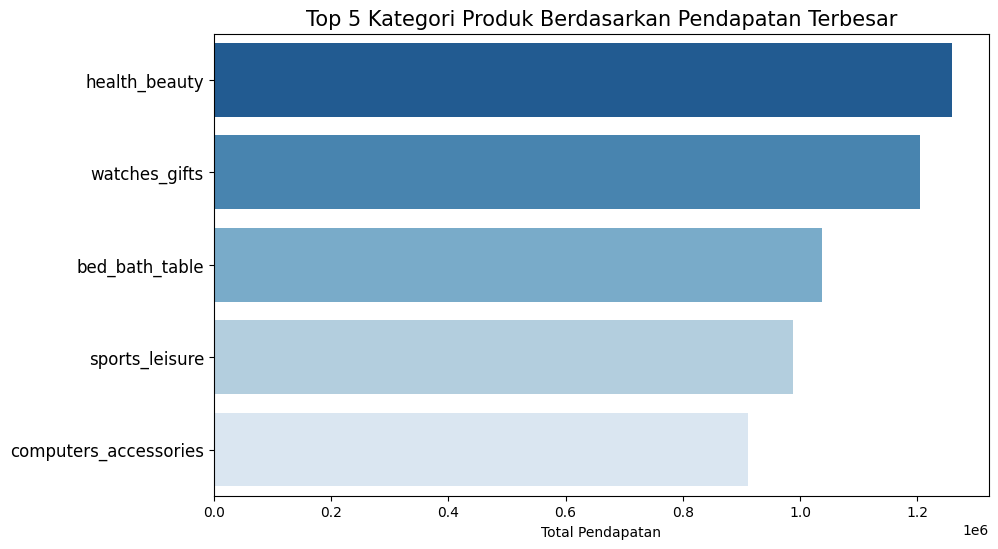

In [ ]:
plt.figure(figsize=(10, 6))

top_5_categories = revenue_by_category.head(5)

sns.barplot(
    y="Kategori_Produk",
    x="Total_Pendapatan",
    data=top_5_categories,
    palette="Blues_r"
)

plt.title("Top 5 Kategori Produk Berdasarkan Pendapatan Terbesar", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel("Total Pendapatan")
plt.tick_params(axis='y', labelsize=12)
plt.show()

### Pertanyaan 2:

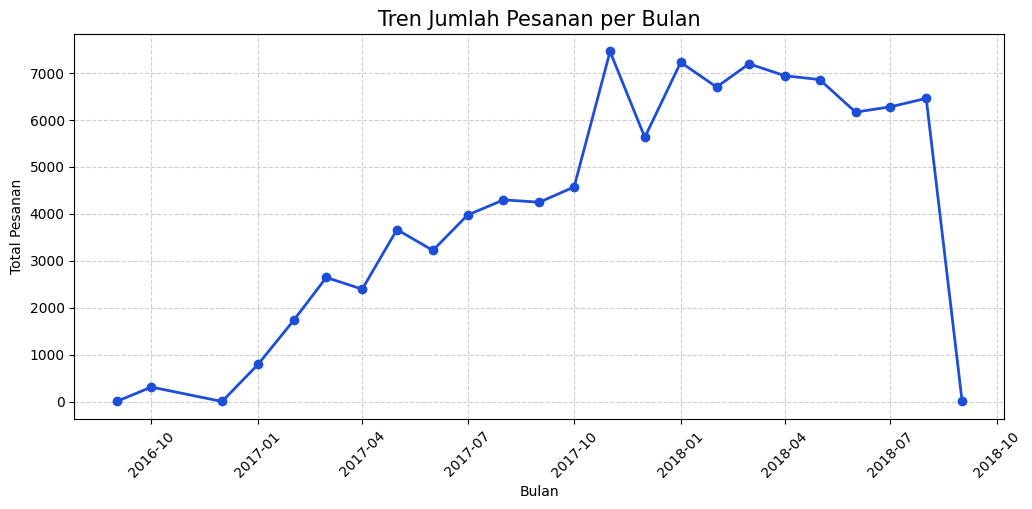

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders["order_month_year"],
    monthly_orders["Jumlah_Pesanan"],
    marker='o',
    linewidth=2,
    color="#1d4ed8"
)

plt.title("Tren Jumlah Pesanan per Bulan", loc="center", fontsize=15)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.xlabel("Bulan")
plt.ylabel("Total Pesanan")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Conclusion

Conclusion Pertanyaan 1: Kategori produk yang memberikan kontribusi total pendapatan (revenue) terbesar bagi perusahaan adalah Health & Beauty (Kesehatan & Kecantikan), disusul oleh Watches & Gifts (Jam Tangan & Hadiah) dan Bed Bath & Table. Hal ini menunjukkan bahwa pengeluaran pelanggan didominasi oleh produk perawatan diri, aksesori, dan perlengkapan rumah.

Conclusion Pertanyaan 2: Tren jumlah pesanan per bulan menunjukkan pertumbuhan yang pesat pada paruh kedua tahun 2017 dan mencapai puncak tertingginya pada bulan November 2017 (kemungkinan didorong oleh event belanja akhir tahun). Memasuki tahun 2018, volume pesanan berhasil stabil di angka yang jauh lebih tinggi dibandingkan awal 2017 (berkisar 6.000 hingga 7.000 pesanan per bulan), yang menunjukkan adopsi pengguna platform semakin baik.